# PART8_Breeding_plan
Simulate breeding plan using selected RILs (N01-162 & N08-011, N17-071 & N08-011)

In [4]:
import random
import copy
import ast
import math
import numpy as np
import pandas as pd
import pickle
from tqdm import tqdm

from sklearn.linear_model import ElasticNet
from modules.make_data_for_prediction import make_data
from modules.training_module import train_Enet
from modules.breeding import make_regional_info, get_top_regions, plot_regional_info, plot_regional_info_with_target, target_effect_summary, visualize_line_genotype, visualize_RIL_genotype
from modules.simulation import get_input_for_recombination, get_recombination_points, convert_genotype_to_pair, cross, check_target_regions, check_approximate_Hitomebore_ratio

## Make marker positions in beneficial & detrimental genomic regions

In [5]:
# genome size
total_length = sum(pd.read_csv("../data/chromosome_length.csv").length.values)

# get recombination points from NAM
with open('../data/PART0_NAM_stats/recombination_stats_500kbp.pic.bin', 'rb') as p:
    recombination_info = pickle.load(p)

NA_contain_RILs = recombination_info[recombination_info["count"] == -1].id.unique()
recombination_info = recombination_info[~recombination_info.id.isin(NA_contain_RILs)]
input_recom_data = get_input_for_recombination(recombination_info)

# genotype with start and end
genotype = pd.read_csv("../data/PART1_make_Haplotype_block/Haplotype_all_LD90.csv")
chr_ends = []
for i, each_chr in enumerate(genotype.chr.unique()):
    chr_genotype = genotype[genotype["chr"] == each_chr]
    pos_array = chr_genotype.pos.str.split("_", expand=True).values.flatten()
    pos_array = pos_array[pos_array != None].astype("int")
    end = pos_array.max()
    chr_ends.append(end)
pos_array = genotype.pos.str.split("_", expand=True).values
pos = np.array([[int(each_pos[0]), int(each_pos[0])] if each_pos[1] == None else [int(each_pos[0]), int(each_pos[1])] for each_pos in pos_array])
genotype["start"] = pos[:, 0]
genotype["end"] = pos[:, 1]

In [6]:
# get target regions indices of genotype data
imp_data = pd.read_csv("../data/PART7_breeding_strategy/Haplotype_high_imp_HBs_for_3traits_add.csv", dtype={'N01':str,'N03':str,'N04':str,'N05':str,'N06':str,'N07':str,'N08':str,'N09':str,'N10':str,'N11':str,'N12':str,'N13':str,'N14':str,'N16':str,'N17':str,'N18':str,'N19':str,'N20':str,'N21':str,'N22':str})

pop = "N01"
regional_info_all = make_regional_info(imp_data, 1000000, "../data/PART7_breeding_strategy/Haplotype_high_imp_HBs_for_3traits.csv", pop)
N01_GN_top_regions = get_top_regions(regional_info_all, "GN_imps", "top", 3)
N01_GN_top_regions_indices = []
for i in N01_GN_top_regions:
    N01_GN_top_regions_indices.extend(genotype[(genotype.chr == i[0]) & (genotype.start >= i[1]) & (genotype.end <= i[2]) & (genotype.N01_162 == 2)].index.values)

pop = "N17"
regional_info_all = make_regional_info(imp_data, 1000000, "../data/PART7_breeding_strategy/Haplotype_high_imp_HBs_for_3traits.csv", pop)
N17_GN_top_regions = get_top_regions(regional_info_all, "GN_imps", "top", 3)
N17_GN_top_regions_indices = []
for i in N17_GN_top_regions:
    N17_GN_top_regions_indices.extend(genotype[(genotype.chr == i[0]) & (genotype.start >= i[1]) & (genotype.end <= i[2]) & (genotype.N17_071 == 2)].index.values)

pop = "N08"
regional_info_all = make_regional_info(imp_data, 1000000, "../data/PART7_breeding_strategy/Haplotype_high_imp_HBs_for_3traits.csv", pop)
N08_PN_top_regions = get_top_regions(regional_info_all, "PN_imps", "top", 3)
N08_PN_top_regions_indices = []
for i in N08_PN_top_regions:
    N08_PN_top_regions_indices.extend(genotype[(genotype.chr == i[0]) & (genotype.start >= i[1]) & (genotype.end <= i[2]) & (genotype.N08_011 == 2)].index.values)

pop = "N04"
regional_info_all = make_regional_info(imp_data, 1000000, "../data/PART7_breeding_strategy/Haplotype_high_imp_HBs_for_3traits.csv", pop)
N04_PN_top_regions = get_top_regions(regional_info_all, "PN_imps", "top", 3)
N04_PN_top_regions_indices = []
for i in N04_PN_top_regions:
    N04_PN_top_regions_indices.extend(genotype[(genotype.chr == i[0]) & (genotype.start >= i[1]) & (genotype.end <= i[2]) & (genotype.N04_037 == 2)].index.values)

In [7]:
# get marker info for prediction model
marker_for_pred = imp_data.loc[:, ["chr", "start", "end"]]
marker_for_pred["key"] = marker_for_pred["chr"] + "_" + marker_for_pred["start"].astype("str") + "_" + marker_for_pred["end"].astype("str")

In [190]:
# marker list
N01_keep_marker_list = [[34303, 35049], [350, 1262], [29062, 29936]]
N08_keep_marker_list = [[20229, 21153], [56277, 56964]]
N17_keep_marker_list = [[624, 1450], [29254, 30167], [26960, 27486]]
N04_keep_marker_list = [[6947, 7695], [20230, 21125], [56283, 56964]]
N01_drop_marker_list = [[2636, 3713], [6857, 8547], [10886, 11845],[11858, 11965], [13089, 13787], [14278, 14506], [16922, 16949], [16950, 17819], [20314, 20504], [21631, 21674], [21677, 21962], [26167, 28462], [38200, 39517], [41461, 41920], [42778, 45233], [46432, 47905], [50254, 52526], [56261, 57080]]
N08_drop_marker_list = [[2698, 4760], [16123, 16942], [20044, 20100], [21440, 21577], [21677, 22021], [24718, 25816], [31325, 32235], [35069, 35430], [36325, 38191], [39522, 40592], [42677, 42743], [46108, 46429], [46432, 47262], [48260, 52526], [52826, 56174]]
N17_drop_marker_list = [[3504, 3597], [5894, 7704], [10415, 10648], [11963, 11973], [12621, 13371], [15485, 15887], [18397, 18430], [23356, 24180], [30398, 30776], [35066, 36302], [36595, 38480], [40591, 41253], [41626, 42136], [46343, 46429], [47973, 49111], [52530, 52571], [55261, 55286], [56272, 57081]]
N04_drop_marker_list = [[5422, 5706], [11299, 11845], [11846, 14173], [22937, 24081], [24718, 30397], [34252, 35056], [35064, 35804], [41796, 42744], [46432, 52525], [52548, 52914]]

In [196]:
def make_visualize_markers(genotype, marker_list):
    tmp_markers = []
    for i in marker_list:
        tmp_marker_region = genotype.iloc[i[0]:i[1]]
        region_width = tmp_marker_region.end.values[-1] - tmp_marker_region.start.values[0]
        if region_width < 2500000:
            tmp_markers.append([tmp_marker_region.chr.values[0], tmp_marker_region.start.values[0], tmp_marker_region.start.values[0]+500000])
        elif region_width < 5000000:
            tmp_markers.append([tmp_marker_region.chr.values[0], tmp_marker_region.start.values[0], tmp_marker_region.start.values[0]+500000])
            tmp_markers.append([tmp_marker_region.chr.values[0], tmp_marker_region.start.values[-1], tmp_marker_region.start.values[-1]+500000])            
        else:
            for j in np.linspace(tmp_marker_region.start.values[0], tmp_marker_region.start.values[-1], region_width // 2500000, endpoint = True, retstep = False, dtype = int):
                tmp_markers.append([tmp_marker_region.chr.values[0], j, j+500000])
    return tmp_markers 

def make_marker_index(genotype, marker_positions, RIL_id):
    marker_index = []
    for i in marker_positions:
        tmp_genotype = genotype.loc[(genotype.chr == i[0]) & (genotype[RIL_id] != 0)]
        marker_index.append(tmp_genotype[(tmp_genotype.start <= i[1])].index.values[-1])
    return marker_index

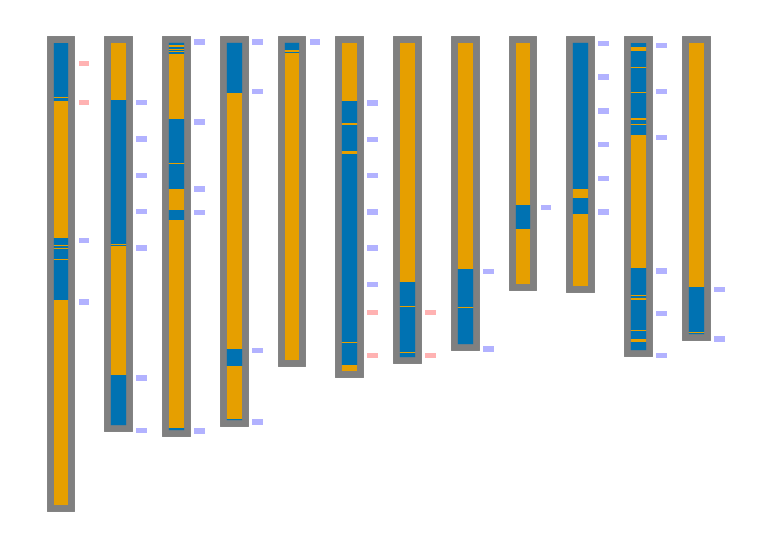

In [193]:
tmp_genotype = genotype.loc[:, ["chr", "start", "end", "N01_162"]]
N01_keep_markers_vis = make_visualize_markers(genotype, N01_keep_marker_list)
N01_drop_markers_vis = make_visualize_markers(genotype, N01_drop_marker_list)
visualize_RIL_genotype(tmp_genotype, chr_ends, "#E69F00", "#0072B2", N01_keep_markers_vis, N01_drop_markers_vis, 80)
N01_keep_marker_index = make_marker_index(tmp_genotype, N01_keep_markers_vis, "N01_162")
N01_drop_marker_index = make_marker_index(tmp_genotype, N01_drop_markers_vis, "N01_162")

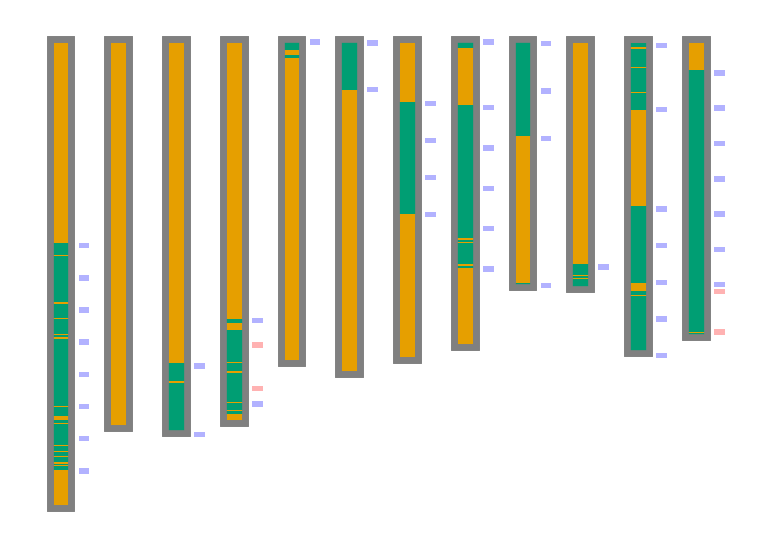

In [194]:
tmp_genotype = genotype.loc[:, ["chr", "start", "end", "N08_011"]]
N08_keep_markers_vis = make_visualize_markers(genotype, N08_keep_marker_list)
N08_drop_markers_vis = make_visualize_markers(genotype, N08_drop_marker_list)
visualize_RIL_genotype(tmp_genotype, chr_ends, "#E69F00", "#009E73", N08_keep_markers_vis, N08_drop_markers_vis, 80)
N08_keep_marker_index = make_marker_index(tmp_genotype, N08_keep_markers_vis, "N08_011")
N08_drop_marker_index = make_marker_index(tmp_genotype, N08_drop_markers_vis, "N08_011")

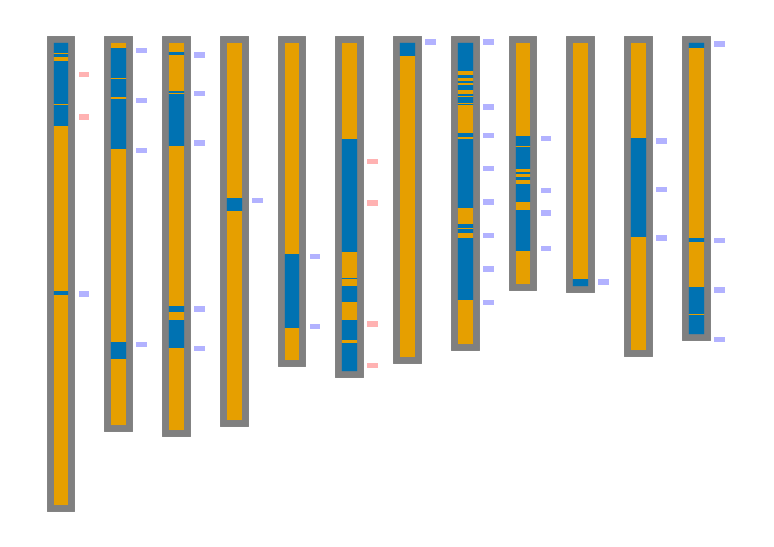

In [195]:
tmp_genotype = genotype.loc[:, ["chr", "start", "end", "N17_071"]]
N17_keep_markers_vis = make_visualize_markers(genotype, N17_keep_marker_list)
N17_drop_markers_vis = make_visualize_markers(genotype, N17_drop_marker_list)
visualize_RIL_genotype(tmp_genotype, chr_ends, "#E69F00", "#0072B2", N17_keep_markers_vis, N17_drop_markers_vis, 80)
N17_keep_marker_index = make_marker_index(tmp_genotype, N17_keep_markers_vis, "N17_071")
N17_drop_marker_index = make_marker_index(tmp_genotype, N17_drop_markers_vis, "N17_071")

# Prepare selected RILs & Hitomebore genotype

In [11]:
genotype_Hitomebore = genotype.loc[:, ["chr", "start", "end"]]
genotype_Hitomebore = pd.concat([genotype_Hitomebore,
                                 pd.DataFrame({"Hitomebore_1"      :np.repeat(0, genotype_Hitomebore.shape[0]),
                                               "Hitomebore_1_color":np.repeat("Hitomebore", genotype_Hitomebore.shape[0]),
                                               "Hitomebore_2"      :np.repeat(0, genotype_Hitomebore.shape[0]),
                                               "Hitomebore_2_color":np.repeat("Hitomebore", genotype_Hitomebore.shape[0])})],
                                axis=1)

genotype_N01_162 = pd.concat([genotype.loc[:, ["chr", "start", "end"]],
                              convert_genotype_to_pair(genotype["N01_162"].values, "N01_162")],
                             axis=1)
genotype_N17_071 = pd.concat([genotype.loc[:, ["chr", "start", "end"]],
                              convert_genotype_to_pair(genotype["N17_071"].values, "N17_071")],
                             axis=1)
genotype_N08_011 = pd.concat([genotype.loc[:, ["chr", "start", "end"]],
                              convert_genotype_to_pair(genotype["N08_011"].values, "N08_011")],
                             axis=1)
genotype_N04_037 = pd.concat([genotype.loc[:, ["chr", "start", "end"]],
                              convert_genotype_to_pair(genotype["N04_037"].values, "N04_037")],
                             axis=1)

# Simulation 

In [12]:
RIL_info = {
    "N01_162": [genotype_N01_162, N01_GN_top_regions_indices],
    "N17_071": [genotype_N17_071, N17_GN_top_regions_indices],
    "N08_011": [genotype_N08_011, N08_PN_top_regions_indices],
    "N04_037": [genotype_N04_037, N04_PN_top_regions_indices]   
}

In [13]:
def BCF2(RIL, genotype_RIL, genotype_Hitomebore, input_recom_data, simulation_num):
    BCF1_genotype = cross(genotype_RIL, genotype_Hitomebore, RIL, "Hitomebore", "BCF1", input_recom_data)
    BCF2_genotypes = []
    for i in range(simulation_num):
        BCF2_genotypes.append(cross(BCF1_genotype, BCF1_genotype, "BCF1", "BCF1", "BCF2", input_recom_data))
    return BCF2_genotypes

def get_genotypes_with_targets(genotype_list, name, marker_list):
    genotype_list_with_targets = []
    genotype_list_with_targets_homo = []
    for each_genotype in genotype_list:
        marker_genotype = each_genotype.loc[np.array(marker_list).flatten(), [f"{name}_1", f"{name}_2"]].sum(axis=1)
        if (marker_genotype > 0).sum() == len(np.array(marker_list).flatten()):
            genotype_list_with_targets.append(each_genotype)
        if (marker_genotype == 2).sum() == len(np.array(marker_list).flatten()):
            genotype_list_with_targets_homo.append(each_genotype)
    return genotype_list_with_targets, genotype_list_with_targets_homo

def get_sum_of_marker_genotype(genotype_list, name, marker_list):
    sum_marker = []
    for each_genotype in genotype_list:
        sum_marker.append(each_genotype.loc[np.array(marker_list).flatten(), [f"{name}_1", f"{name}_2"]].sum().sum())
    return np.array(sum_marker)

# Simulate New cultivar from N01_162 & N08_011

In [14]:
random.seed(1024)

simulation_times = 100
Final_cultivars_Hitome_ratio = []
Final_cultivars_genotype = []
Final_cultivars_homo = []
fav_progenie_nums = []
for i in tqdm(range(simulation_times)):

    BCF2_num = 100
    # N01_162 x Hitomebore -> BCF1 -> 100 BCF2 
    # -> random select 1 BCF2 with target variants
    BCF2_N01_162 = BCF2("N01_162", RIL_info["N01_162"][0], genotype_Hitomebore, input_recom_data, BCF2_num)
    BCF2_N01_162_with_target, BCF2_N01_162_with_target_homo = get_genotypes_with_targets(BCF2_N01_162, "BCF2", N01_keep_marker_index)
    if len(BCF2_N01_162_with_target_homo) > 0:
        sum_marker = get_sum_of_marker_genotype(BCF2_N01_162_with_target_homo, "BCF2", N01_drop_marker_index)
        BCF2_N01_162_cand = BCF2_N01_162_with_target_homo[sum_marker.argsort()[0]]
    else:
        sum_marker = get_sum_of_marker_genotype(BCF2_N01_162_with_target, "BCF2", N01_drop_marker_index)
        BCF2_N01_162_cand = BCF2_N01_162_with_target[sum_marker.argsort()[0]]

    # N08_011 x Hitomebore -> BCF1 -> 100 BCF2 
    # -> random select 1 BCF2 with target variants
    BCF2_N08_011 = BCF2("N08_011", RIL_info["N08_011"][0], genotype_Hitomebore, input_recom_data, BCF2_num)
    BCF2_N08_011_with_target, BCF2_N08_011_with_target_homo = get_genotypes_with_targets(BCF2_N08_011, "BCF2", N08_keep_marker_index)
#     print("BCF2 lines with N08 target variants:", len(BCF2_N08_011_with_target) / BCF2_num, len(BCF2_N08_011_with_target_homo) / BCF2_num)
    if len(BCF2_N08_011_with_target_homo) > 0:
        sum_marker = get_sum_of_marker_genotype(BCF2_N08_011_with_target_homo, "BCF2", N08_drop_marker_index)
        BCF2_N08_011_cand = BCF2_N08_011_with_target_homo[sum_marker.argsort()[0]]
    else:
        sum_marker = get_sum_of_marker_genotype(BCF2_N08_011_with_target, "BCF2", N08_drop_marker_index)
        BCF2_N08_011_cand = BCF2_N08_011_with_target[sum_marker.argsort()[0]]
        
    # BCF2_N01_162_cand x BCF2_N08_011_cand
    # -> random select 1 progeny with target variants & high Hitomebore ratio
    mix_num = 100
    both_keep_marker = copy.copy(N01_keep_marker_index)
    both_keep_marker.extend(N08_keep_marker_index)
    mixed = [cross(BCF2_N01_162_cand, BCF2_N08_011_cand, "BCF2", "BCF2", "N01_N08_mixed", input_recom_data) for j in range(mix_num)]
    mixed_with_targets, _ = get_genotypes_with_targets(mixed, "N01_N08_mixed", both_keep_marker)
    both_drop_marker = copy.copy(N01_drop_marker_index)
    both_drop_marker.extend(N08_drop_marker_index)
    sum_marker = get_sum_of_marker_genotype(mixed_with_targets, "N01_N08_mixed", both_drop_marker)
    mixed_cand = mixed_with_targets[sum_marker.argsort()[0]]
    # -> inbreed to fix target variants
    mixed_2nd = [cross(mixed_cand, mixed_cand, "N01_N08_mixed", "N01_N08_mixed", "N01_N08_mixed_2nd", input_recom_data) for j in range(mix_num)]
    mixed_2nd_with_targets, mixed_2nd_with_targets_homo = get_genotypes_with_targets(mixed_2nd, "N01_N08_mixed_2nd", both_keep_marker)
    mixed_2nd_target_homo_ratio = get_sum_of_marker_genotype(mixed_2nd_with_targets, "N01_N08_mixed_2nd", both_keep_marker)
    mixed_cand = mixed_2nd_with_targets[mixed_2nd_target_homo_ratio.argsort()[-1]]
    # -> inbreed progeny that have highest homozygosity of target regions to fix target variants
    mixed_3rd = [cross(mixed_cand, mixed_cand, "N01_N08_mixed_2nd", "N01_N08_mixed_2nd", "N01_N08_mixed_3rd", input_recom_data) for j in range(mix_num)]
    mixed_3rd_with_targets, mixed_3rd_with_targets_homo = get_genotypes_with_targets(mixed_3rd, "N01_N08_mixed_3rd", both_keep_marker)
    sum_marker = get_sum_of_marker_genotype(mixed_3rd_with_targets_homo, "N01_N08_mixed_3rd", both_drop_marker)
#     print(check_approximate_Hitomebore_ratio(mixed_3rd_with_targets_homo[sum_marker.argsort()[0]], "N01_N08_mixed_3rd", total_length))
    if len(mixed_3rd_with_targets_homo) > 0:
        Final_cultivars_Hitome_ratio.append(check_approximate_Hitomebore_ratio(mixed_3rd_with_targets_homo[sum_marker.argsort()[0]], "N01_N08_mixed_3rd", total_length))
        Final_cultivars_genotype.append(mixed_3rd_with_targets_homo[sum_marker.argsort()[0]])
        Final_cultivars_homo.append(True)
    else:
        mixed_3rd_target_homo_ratio = get_sum_of_marker_genotype(mixed_3rd_with_targets, "N01_N08_mixed_3rd", both_keep_marker)
        Final_cultivars_Hitome_ratio.append(check_approximate_Hitomebore_ratio(mixed_3rd_with_targets[mixed_3rd_target_homo_ratio.argsort()[-1]], "N01_N08_mixed_3rd", total_length))
        Final_cultivars_genotype.append(mixed_3rd_with_targets[mixed_3rd_target_homo_ratio.argsort()[-1]])
        Final_cultivars_homo.append(False)
    fav_progenie_nums.append([len(BCF2_N01_162_with_target), len(BCF2_N01_162_with_target_homo), len(BCF2_N08_011_with_target), len(BCF2_N08_011_with_target_homo), len(mixed_with_targets), len(mixed_3rd_with_targets_homo)])


100%|██████████| 100/100 [3:16:05<00:00, 117.65s/it] 


In [15]:
pd.DataFrame(fav_progenie_nums).to_csv("../data/PART9_Breeding_plan/N01_162_N08_011_selection_stats.csv")
SNP_merged_num = marker_for_pred.shape[0]
Hitome_genotype = np.repeat(0, marker_for_pred.shape[0])
predict_genotype = [Hitome_genotype]
predict_genotype_name = ["Hitomebore"]
for i, convert_genotype in enumerate(Final_cultivars_genotype):
    convert_genotype["genotype"] = convert_genotype.loc[:, ["N01_N08_mixed_3rd_1", "N01_N08_mixed_3rd_2"]].sum(axis=1)
    convert_genotype["key"] = convert_genotype["chr"] + "_" + convert_genotype["start"].astype('str') + "_" + convert_genotype["end"].astype('str')
    convert_genotype = convert_genotype[convert_genotype.key.isin(marker_for_pred["key"])]
    predict_genotype.append(convert_genotype.genotype.values)
    predict_genotype_name.append(f"simulate_{i}")
predict_genotype = pd.DataFrame(predict_genotype)
predict_genotype.index = predict_genotype_name

In [16]:
family_list = pd.read_csv("../data/family_list.csv")
family = family_list.family.unique()
k = 1
phenotype = "../data/phenotype_data/mean_phenotypes.csv"
CV = 5
Hitome_ratio = [1]
Hitome_ratio.extend(Final_cultivars_Hitome_ratio)
target_homo = [False]
target_homo.extend(Final_cultivars_homo)
predicted_data = [Hitome_ratio, target_homo]
rate = np.repeat(1, len(Hitome_ratio))
for trait_name in ["GN_mean", "PN_mean", "Area.size.AS..mm2."]:
    print(trait_name)
    genotype_path = "../data/PART7_breeding_strategy/Haplotype_high_imp_HBs_for_3traits.csv" 
    test_data, train_data, position_data = make_data(family, family_list, trait_name, genotype_path, phenotype, CV, seed=1024, plot=False, log=False)
    ideal_preds = []
    for i in range(CV):
        Enet_params = pd.read_csv("../data/PART7_breeding_strategy/Enet_high_imp_HBs_params.csv", index_col=0)
        Enet_params.columns = ["trait", "CV", "params"]
        Enet_params = ast.literal_eval(Enet_params.loc[(Enet_params["trait"] == trait_name) & (Enet_params["CV"] == i), "params"].values[0])
        tmp_train_data = train_data[i] 
        X_train = tmp_train_data[0].fillna(1)
        y_train = tmp_train_data[1]
        # train model
        clf = ElasticNet(alpha=Enet_params["alpha"], l1_ratio=Enet_params["l1_ratio"], max_iter=100000)
        clf.fit(X_train, y_train)
        # predicted values of test phenotype
        ideal_pred = clf.predict(predict_genotype)
        ideal_preds.append(ideal_pred)
    ideal_preds = np.mean(ideal_preds, axis=0)
    rate = [each_rate*ideal_preds[k]/ideal_preds[0] for k, each_rate in enumerate(rate)]
    predicted_data.append(ideal_preds)
predicted_data.append(rate)
predicted_data = pd.DataFrame(predicted_data)
predicted_data.index = ["Hitome_ratio", "target_homo", "GN_mean", "PN_mean", "Area.size.AS..mm2.", "rate"]
predicted_data.columns = predict_genotype_name
predicted_data.to_csv("../data/PART9_Breeding_plan/N01_162_N08_011_simulation.csv")
predicted_data

GN_mean
PN_mean
Area.size.AS..mm2.


,Hitomebore,simulate_0,simulate_1,simulate_2,simulate_3,simulate_4,simulate_5,simulate_6,simulate_7,simulate_8,...,simulate_90,simulate_91,simulate_92,simulate_93,simulate_94,simulate_95,simulate_96,simulate_97,simulate_98,simulate_99
Hitome_ratio,1,0.790845,0.752128,0.835481,0.84168,0.827992,0.866604,0.846561,0.782665,0.721647,...,0.858896,0.784333,0.845135,0.828897,0.883527,0.836723,0.783565,0.874083,0.866106,0.832047
target_homo,False,True,True,False,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
GN_mean,111.367888,156.127745,171.644865,183.459876,157.415367,165.829529,157.570069,178.778466,162.653032,169.26825,...,156.433548,175.000067,159.202179,176.135795,163.855474,175.542974,161.320745,159.470677,163.143163,157.041611
PN_mean,14.557327,16.390562,16.480639,15.185226,16.09796,15.056083,15.182146,16.064158,15.690524,17.415286,...,16.274165,15.349219,16.391011,14.293946,15.858073,15.751467,14.177754,15.87159,16.292302,16.024211
Area.size.AS..mm2.,17.142273,16.447984,16.449865,15.970551,17.089741,16.828054,16.908087,15.404441,16.170156,16.010405,...,15.989595,15.534435,16.088145,15.724035,15.817338,16.016318,16.729544,16.506911,16.451706,16.833026
rate,1.0,1.514525,1.674392,1.60093,1.558273,1.511812,1.45543,1.591875,1.484923,1.698238,...,1.464725,1.501447,1.510604,1.424471,1.478886,1.593519,1.376803,1.50334,1.573447,1.524206


## Simulation results

## Phenotypic values of GN, PN, GS

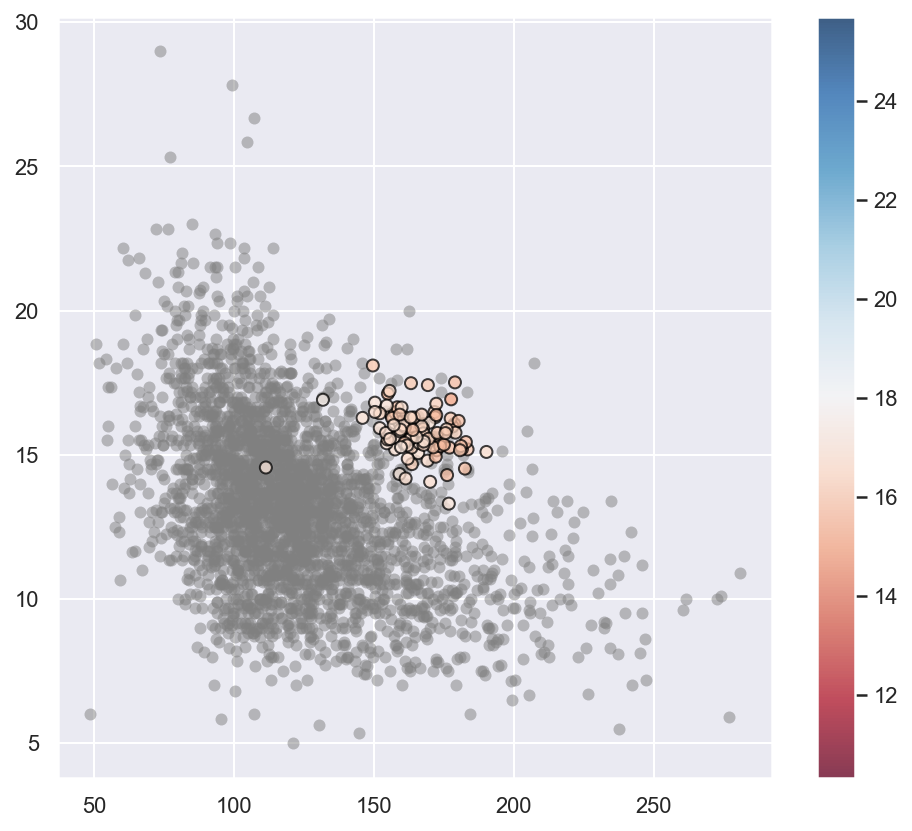

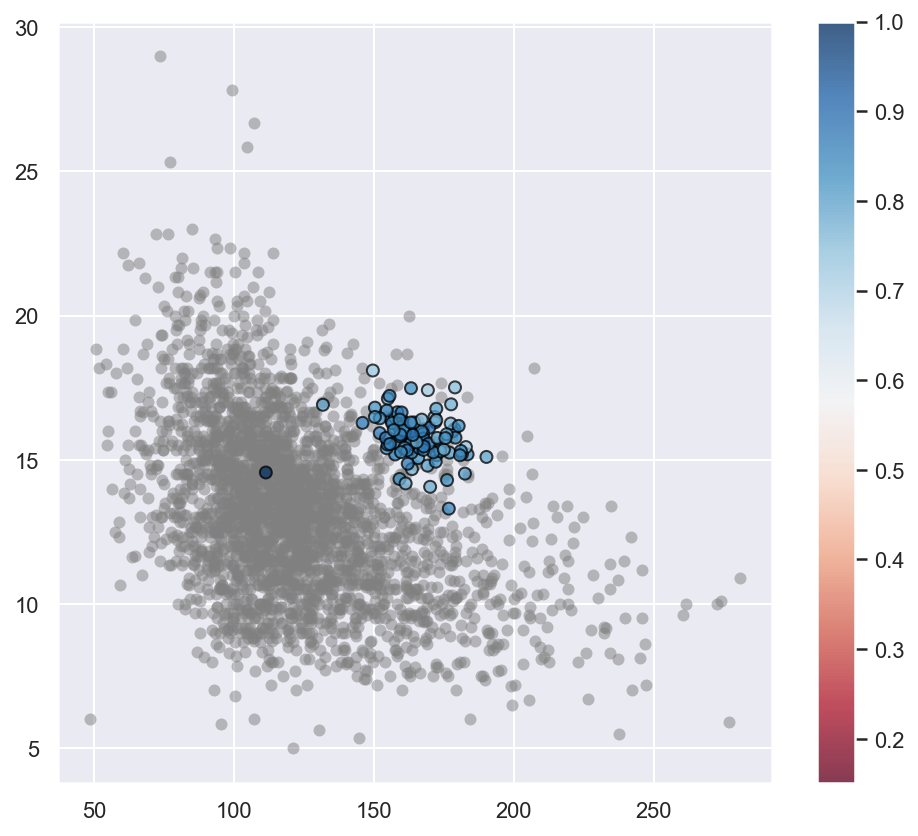

In [261]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
%matplotlib inline
%config InlineBackend.figure_formats = {'png', 'retina'}
sns.set()

phenotype_data = pd.read_csv("../data/phenotype_data/mean_phenotypes.csv", index_col=0)
NAM_Hitome_ratio = pd.read_csv("../data/PART0_NAM_stats/Percentage_Hitomebore_genotype.csv")

simulation_results = pd.read_csv("../data/PART9_Breeding_plan/N01_162_N08_011_simulation.csv", index_col=0)
simulation_results_scatter = simulation_results.T

plt.figure(figsize=(8,7))
sc = plt.scatter(phenotype_data["GN_mean"], phenotype_data["PN_mean"], alpha=0.5, linewidths=0, color="gray")
sc = plt.scatter(simulation_results_scatter["GN_mean"].astype(float), simulation_results_scatter["PN_mean"].astype(float),
                 c=simulation_results_scatter["Area.size.AS..mm2."].astype(float), alpha=0.75, edgecolor="black", cmap="RdBu",
                 vmin=phenotype_data["Area.size.AS..mm2."].min(), vmax=phenotype_data["Area.size.AS..mm2."].max())
plt.colorbar(sc)
plt.show()

plt.figure(figsize=(8,7))
sc = plt.scatter(phenotype_data["GN_mean"], phenotype_data["PN_mean"], alpha=0.5, linewidths=0, color="gray")
sc = plt.scatter(simulation_results_scatter["GN_mean"].astype(float), simulation_results_scatter["PN_mean"].astype(float),
                 c=simulation_results_scatter["Hitome_ratio"].astype(float), alpha=0.75, edgecolor="black", cmap="RdBu",
                 vmin=NAM_Hitome_ratio["Hitomebore_per"].min(), vmax=NAM_Hitome_ratio["Hitomebore_per"].max())
plt.colorbar(sc)
plt.show()

## Average phenotypic values of new line

In [19]:
simulation_results = pd.read_csv("../data/PART9_Breeding_plan/N01_162_N08_011_simulation.csv", index_col=0)
simulation_results = simulation_results.iloc[[0,2,3,4,5]].astype(float)
simulation_results = pd.concat([simulation_results.iloc[:, 0], simulation_results.iloc[:, 1:].mean(axis=1), simulation_results.iloc[:, 1:].std(axis=1)], axis=1)
simulation_results.columns = ["Hitomebore", "simulation_mean", "simulation_std"]
simulation_results

,Hitomebore,simulation_mean,simulation_std
Hitome_ratio,1.000000,0.830531,0.041138
GN_mean,111.367888,165.488648,9.671637
PN_mean,14.557327,15.814006,0.770792
Area.size.AS..mm2.,17.142273,16.373640,0.491144
rate,1.000000,1.538600,0.076809


## Compare Htomebore

In [20]:
simulation_results.simulation_mean / simulation_results.Hitomebore

Hitome_ratio          0.830531
GN_mean               1.485964
PN_mean               1.086326
Area.size.AS..mm2.    0.955162
rate                  1.538600
dtype: float64

# Simulate New cultivar from N17_071 & N08_011

In [21]:
random.seed(1024)

simulation_times = 100
Final_cultivars_Hitome_ratio = []
Final_cultivars_genotype = []
Final_cultivars_homo = []
for i in tqdm(range(simulation_times)):
    
    BCF2_num = 100
    # N17_071 x Hitomebore -> BCF1 -> 100 BCF2 
    # -> random select 1 BCF2 with target variants
    BCF2_N17_071 = BCF2("N17_071", RIL_info["N17_071"][0], genotype_Hitomebore, input_recom_data, BCF2_num)
    BCF2_N17_071_with_target, BCF2_N17_071_with_target_homo = get_genotypes_with_targets(BCF2_N17_071, "BCF2", N17_keep_marker_index)
    if len(BCF2_N17_071_with_target_homo) > 0:
        sum_marker = get_sum_of_marker_genotype(BCF2_N17_071_with_target_homo, "BCF2", N17_drop_marker_index)
        BCF2_N17_071_cand = BCF2_N17_071_with_target_homo[sum_marker.argsort()[0]]
    else:
        sum_marker = get_sum_of_marker_genotype(BCF2_N17_071_with_target, "BCF2", N17_drop_marker_index)
        BCF2_N17_071_cand = BCF2_N17_071_with_target[sum_marker.argsort()[0]]

    # N08_011 x Hitomebore -> BCF1 -> 100 BCF2 
    # -> random select 1 BCF2 with target variants
    BCF2_N08_011 = BCF2("N08_011", RIL_info["N08_011"][0], genotype_Hitomebore, input_recom_data, BCF2_num)
    BCF2_N08_011_with_target, BCF2_N08_011_with_target_homo = get_genotypes_with_targets(BCF2_N08_011, "BCF2", N08_keep_marker_index)
#     print("BCF2 lines with N08 target variants:", len(BCF2_N08_011_with_target) / BCF2_num, len(BCF2_N08_011_with_target_homo) / BCF2_num)
    if len(BCF2_N08_011_with_target_homo) > 0:
        sum_marker = get_sum_of_marker_genotype(BCF2_N08_011_with_target_homo, "BCF2", N08_drop_marker_index)
        BCF2_N08_011_cand = BCF2_N08_011_with_target_homo[sum_marker.argsort()[0]]
    else:
        sum_marker = get_sum_of_marker_genotype(BCF2_N08_011_with_target, "BCF2", N08_drop_marker_index)
        BCF2_N08_011_cand = BCF2_N08_011_with_target[sum_marker.argsort()[0]]
        
    # BCF2_N17_071_cand x BCF2_N08_011_cand
    # -> random select 1 progeny with target variants & high Hitomebore ratio
    mix_num = 100
    both_keep_marker = copy.copy(N17_keep_marker_index)
    both_keep_marker.extend(N08_keep_marker_index)
    mixed = [cross(BCF2_N17_071_cand, BCF2_N08_011_cand, "BCF2", "BCF2", "N17_N08_mixed", input_recom_data) for j in range(mix_num)]
    mixed_with_targets, _ = get_genotypes_with_targets(mixed, "N17_N08_mixed", both_keep_marker)
    both_drop_marker = copy.copy(N17_drop_marker_index)
    both_drop_marker.extend(N08_drop_marker_index)
    sum_marker = get_sum_of_marker_genotype(mixed_with_targets, "N17_N08_mixed", both_drop_marker)
    mixed_cand = mixed_with_targets[sum_marker.argsort()[0]]
    # -> inbreed to fix target variants
    mixed_2nd = [cross(mixed_cand, mixed_cand, "N17_N08_mixed", "N17_N08_mixed", "N17_N08_mixed_2nd", input_recom_data) for j in range(mix_num)]
    mixed_2nd_with_targets, mixed_2nd_with_targets_homo = get_genotypes_with_targets(mixed_2nd, "N17_N08_mixed_2nd", both_keep_marker)
    mixed_2nd_target_homo_ratio = get_sum_of_marker_genotype(mixed_2nd_with_targets, "N17_N08_mixed_2nd", both_keep_marker)
    mixed_cand = mixed_2nd_with_targets[mixed_2nd_target_homo_ratio.argsort()[-1]]
    # -> inbreed progeny that have highest homozygosity of target regions to fix target variants
    mixed_3rd = [cross(mixed_cand, mixed_cand, "N17_N08_mixed_2nd", "N17_N08_mixed_2nd", "N17_N08_mixed_3rd", input_recom_data) for j in range(mix_num)]
    mixed_3rd_with_targets, mixed_3rd_with_targets_homo = get_genotypes_with_targets(mixed_3rd, "N17_N08_mixed_3rd", both_keep_marker)
    sum_marker = get_sum_of_marker_genotype(mixed_3rd_with_targets_homo, "N17_N08_mixed_3rd", both_drop_marker)
#     print(check_approximate_Hitomebore_ratio(mixed_3rd_with_targets_homo[sum_marker.argsort()[0]], "N17_N08_mixed_3rd", total_length))
    if len(mixed_3rd_with_targets_homo) > 0:
        Final_cultivars_Hitome_ratio.append(check_approximate_Hitomebore_ratio(mixed_3rd_with_targets_homo[sum_marker.argsort()[0]], "N17_N08_mixed_3rd", total_length))
        Final_cultivars_genotype.append(mixed_3rd_with_targets_homo[sum_marker.argsort()[0]])
        Final_cultivars_homo.append(True)
    else:
        mixed_3rd_target_homo_ratio = get_sum_of_marker_genotype(mixed_3rd_with_targets, "N17_N08_mixed_3rd", both_keep_marker)
        Final_cultivars_Hitome_ratio.append(check_approximate_Hitomebore_ratio(mixed_3rd_with_targets[mixed_3rd_target_homo_ratio.argsort()[-1]], "N17_N08_mixed_3rd", total_length))
        Final_cultivars_genotype.append(mixed_3rd_with_targets[mixed_3rd_target_homo_ratio.argsort()[-1]])
        Final_cultivars_homo.append(False)
    fav_progenie_nums.append([len(BCF2_N17_071_with_target), len(BCF2_N17_071_with_target_homo), len(BCF2_N08_011_with_target), len(BCF2_N08_011_with_target_homo), len(mixed_with_targets), len(mixed_3rd_with_targets_homo)])


100%|██████████| 100/100 [3:06:43<00:00, 112.03s/it] 


In [22]:
pd.DataFrame(fav_progenie_nums).to_csv("../data/PART9_Breeding_plan/N17_071_N08_011_selection_stats.csv")
SNP_merged_num = marker_for_pred.shape[0]
Hitome_genotype = np.repeat(0, marker_for_pred.shape[0])
predict_genotype = [Hitome_genotype]
predict_genotype_name = ["Hitomebore"]
for i, convert_genotype in enumerate(Final_cultivars_genotype):
    convert_genotype["genotype"] = convert_genotype.loc[:, ["N17_N08_mixed_3rd_1", "N17_N08_mixed_3rd_2"]].sum(axis=1)
    convert_genotype["key"] = convert_genotype["chr"] + "_" + convert_genotype["start"].astype('str') + "_" + convert_genotype["end"].astype('str')
    convert_genotype = convert_genotype[convert_genotype.key.isin(marker_for_pred["key"])]
    predict_genotype.append(convert_genotype.genotype.values)
    predict_genotype_name.append(f"simulate_{i}")
predict_genotype = pd.DataFrame(predict_genotype)
predict_genotype.index = predict_genotype_name

In [23]:
family_list = pd.read_csv("../data/family_list.csv")
family = family_list.family.unique()
k = 1
phenotype = "../data/phenotype_data/mean_phenotypes.csv"
CV = 5
Hitome_ratio = [1]
Hitome_ratio.extend(Final_cultivars_Hitome_ratio)
target_homo = [False]
target_homo.extend(Final_cultivars_homo)
predicted_data = [Hitome_ratio, target_homo]
rate = np.repeat(1, len(Hitome_ratio))
for trait_name in ["GN_mean", "PN_mean", "Area.size.AS..mm2."]:
    print(trait_name)
    genotype_path = "../data/PART7_breeding_strategy/Haplotype_high_imp_HBs_for_3traits.csv" 
    test_data, train_data, position_data = make_data(family, family_list, trait_name, genotype_path, phenotype, CV, seed=1024, plot=False, log=False)
    ideal_preds = []
    for i in range(CV):
        Enet_params = pd.read_csv("../data/PART7_breeding_strategy/Enet_high_imp_HBs_params.csv", index_col=0)
        Enet_params.columns = ["trait", "CV", "params"]
        Enet_params = ast.literal_eval(Enet_params.loc[(Enet_params["trait"] == trait_name) & (Enet_params["CV"] == i), "params"].values[0])
        tmp_train_data = train_data[i] 
        X_train = tmp_train_data[0].fillna(1)
        y_train = tmp_train_data[1]
        # train model
        clf = ElasticNet(alpha=Enet_params["alpha"], l1_ratio=Enet_params["l1_ratio"], max_iter=100000)
        clf.fit(X_train, y_train)
        # predicted values of test phenotype
        ideal_pred = clf.predict(predict_genotype)
        ideal_preds.append(ideal_pred)
    ideal_preds = np.mean(ideal_preds, axis=0)
    rate = [each_rate*ideal_preds[k]/ideal_preds[0] for k, each_rate in enumerate(rate)]
    predicted_data.append(ideal_preds)
predicted_data.append(rate)
predicted_data = pd.DataFrame(predicted_data)
predicted_data.index = ["Hitome_ratio", "target_homo", "GN_mean", "PN_mean", "Area.size.AS..mm2.", "rate"]
predicted_data.columns = predict_genotype_name
predicted_data.to_csv("../data/PART9_Breeding_plan/N17_071_N08_011_simulation.csv")
predicted_data

GN_mean
PN_mean
Area.size.AS..mm2.


,Hitomebore,simulate_0,simulate_1,simulate_2,simulate_3,simulate_4,simulate_5,simulate_6,simulate_7,simulate_8,...,simulate_90,simulate_91,simulate_92,simulate_93,simulate_94,simulate_95,simulate_96,simulate_97,simulate_98,simulate_99
Hitome_ratio,1,0.781185,0.845244,0.866521,0.857638,0.851698,0.869197,0.876192,0.828223,0.827931,...,0.841455,0.881787,0.763824,0.821554,0.879641,0.842033,0.760006,0.876567,0.833935,0.846564
target_homo,False,True,True,True,True,True,True,True,True,True,...,True,True,True,False,True,True,True,True,True,True
GN_mean,111.367888,165.792142,159.32101,178.709916,173.571422,169.478278,171.841876,177.799718,179.473897,164.29792,...,168.699296,185.928999,176.473532,173.404424,176.230305,149.166603,168.722041,176.939573,186.16078,172.594188
PN_mean,14.557327,17.161659,13.894221,15.6788,16.198977,14.349904,13.607701,14.05434,15.627509,16.879761,...,17.883296,15.296678,17.223249,14.569728,15.652945,16.204008,14.230741,15.556333,16.45813,15.83609
Area.size.AS..mm2.,17.142273,16.32847,17.234853,16.223432,16.825325,16.947293,17.42457,17.179626,16.009115,16.523683,...,16.724803,16.236033,16.709272,17.828253,16.391527,17.88246,17.365612,16.632138,15.825708,16.680348
rate,1.0,1.671701,1.372792,1.635664,1.702234,1.483042,1.466108,1.544704,1.615654,1.648903,...,1.815565,1.661553,1.827436,1.620729,1.626994,1.55529,1.500304,1.647291,1.744704,1.640474


## Simulation results

## Phenotypic values of GN, PN, GS

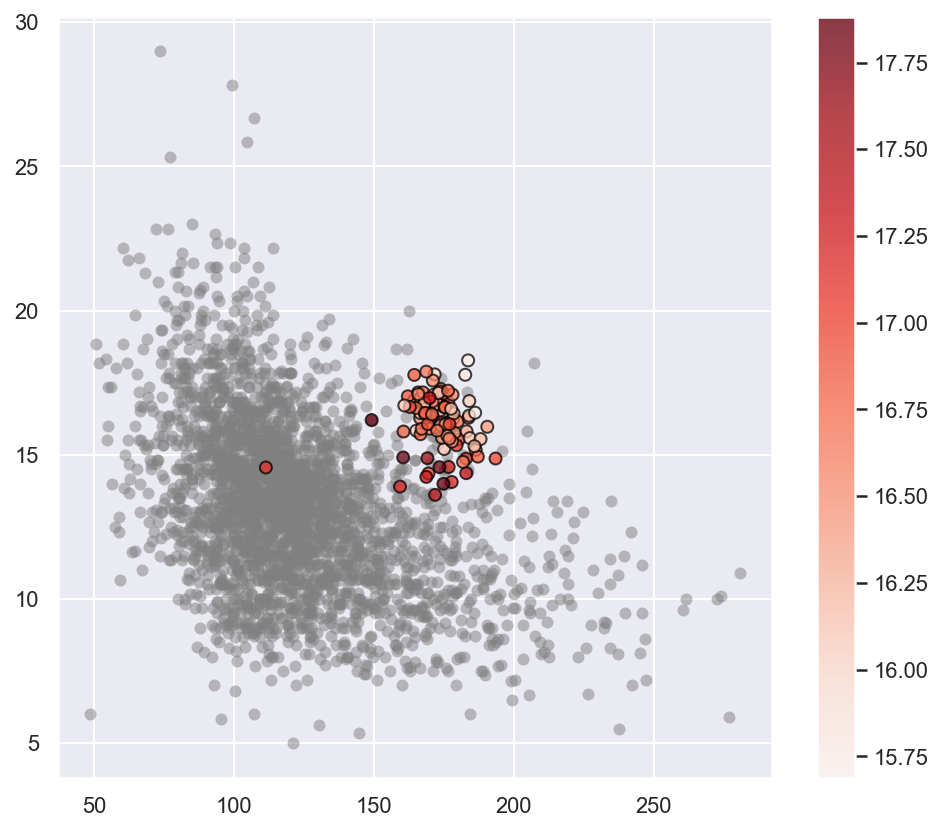

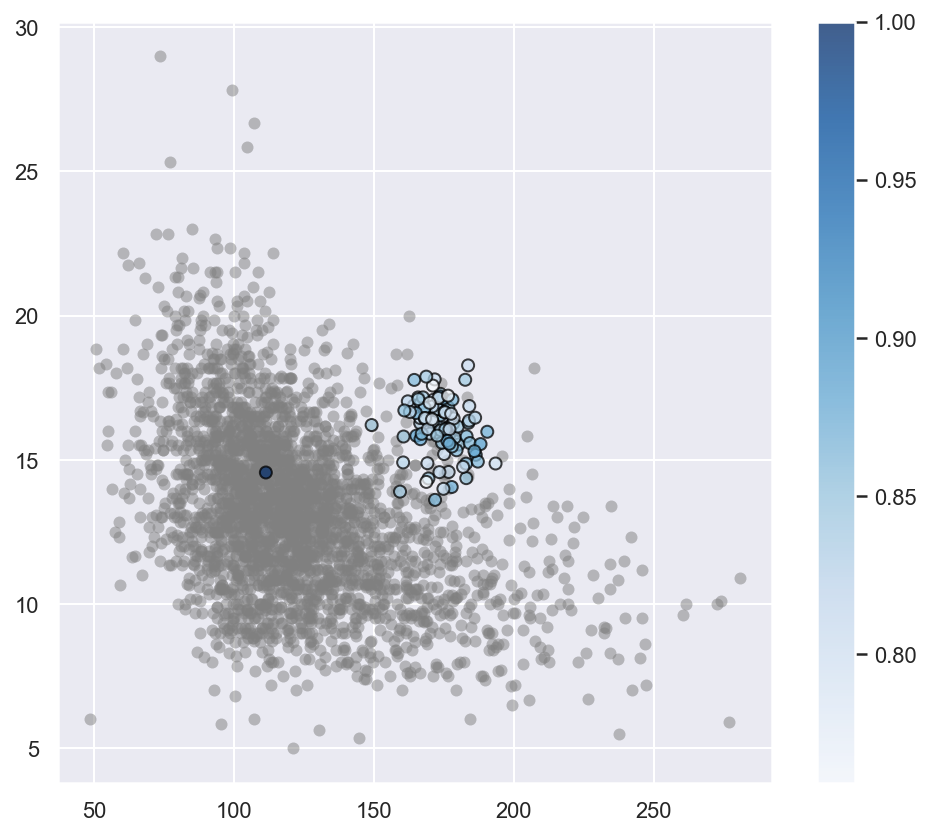

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
%matplotlib inline
%config InlineBackend.figure_formats = {'png', 'retina'}
sns.set()

phenotype_data = pd.read_csv("../data/phenotype_data/mean_phenotypes.csv", index_col=0)

simulation_results = pd.read_csv("../data/PART9_Breeding_plan/N17_071_N08_011_simulation.csv", index_col=0)
# simulation_results = simulation_results.loc[:, simulation_results.loc["target_homo", :] == "True"]
simulation_results_scatter = simulation_results.T

plt.figure(figsize=(8,7))
sc = plt.scatter(phenotype_data["GN_mean"], phenotype_data["PN_mean"], alpha=0.5, linewidths=0, color="gray")
sc = plt.scatter(simulation_results_scatter["GN_mean"].astype(float), simulation_results_scatter["PN_mean"].astype(float), c=simulation_results_scatter["Area.size.AS..mm2."].astype(float), alpha=0.75, edgecolor="black", cmap="Reds")
plt.colorbar(sc)
plt.show()

plt.figure(figsize=(8,7))
sc = plt.scatter(phenotype_data["GN_mean"], phenotype_data["PN_mean"], alpha=0.5, linewidths=0, color="gray")
sc = plt.scatter(simulation_results_scatter["GN_mean"].astype(float), simulation_results_scatter["PN_mean"].astype(float), c=simulation_results_scatter["Hitome_ratio"].astype(float), alpha=0.75, edgecolor="black", cmap="Blues")
plt.colorbar(sc)
plt.show()

## Average phenotypic values of new line

In [26]:
simulation_results = pd.read_csv("../data/PART9_Breeding_plan/N17_071_N08_011_simulation.csv", index_col=0)
simulation_results = simulation_results.iloc[[0,2,3,4,5]].astype(float)
simulation_results = pd.concat([simulation_results.iloc[:, 0], simulation_results.iloc[:, 1:].mean(axis=1), simulation_results.iloc[:, 1:].std(axis=1)], axis=1)
simulation_results.columns = ["Hitomebore", "simulation_mean", "simulation_std"]
simulation_results

,Hitomebore,simulation_mean,simulation_std
Hitome_ratio,1.000000,0.838705,0.030032
GN_mean,111.367888,173.884039,7.457910
PN_mean,14.557327,16.140945,0.957421
Area.size.AS..mm2.,17.142273,16.632293,0.485400
rate,1.000000,1.677043,0.092575


## Compare Hitomebore

In [27]:
simulation_results.simulation_mean / simulation_results.Hitomebore

Hitome_ratio          0.838705
GN_mean               1.561348
PN_mean               1.108785
Area.size.AS..mm2.    0.970250
rate                  1.677043
dtype: float64